# StockPati floorsheet: EDA

## 1. Dataset card

| Item | What I know |
|---|---|
| Source | Local `data/stockpati_floorsheet_full.csv`; [StockPati market site](https://stockpati.com/) describes its NEPSE floorsheet analytics, and [NEPSE's floorsheet page](https://www.nepalstock.com/floor-sheet) identifies the underlying exchange record. |
| Licence | **Not stated for this local CSV.** I have not found a licence or redistribution permission attached to the file. |
| Size | 2,726,159,734 bytes (about 2.54 GiB) on disk. |
| Samples | 17,539,305 transaction rows, 11 columns, 454 symbols, 215 trading dates. |
| Collection | The rows appear to be a StockPati-compiled NEPSE floorsheet export, one matched trade per row. The exact scraping/export procedure and capture date are not documented with this file, so I cannot verify them. |
| Coverage | 2025-07-17 through 2026-07-22, about one year rather than two. |
| Known limits | No clock-time timestamp; transaction-derived last price differs from published close for some stocks; occasional volume differences; unadjusted prices; no confirmed corporate-action, correction, or complete exchange-holiday metadata. |


## 2. Load the CSV, inspect structure, and show five random trades

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import polars as pl

In [2]:

df = pd.read_csv('data/stockpati_floorsheet_full.csv')
print('Shape:', df.shape, "\n")
print('Columns and dtypes:')
print(df.dtypes.to_string(), "\n")
print('Five random trades (seed=42):')
print(df.sample(n=5, random_state=42).to_string(index=False))

Shape: (17539305, 11) 

Columns and dtypes:
date                   object
symbol                 object
company_name           object
contract_no             int64
buyer_broker_code       int64
buyer_broker_name      object
seller_broker_code      int64
seller_broker_name     object
quantity                int64
rate                  float64
amount                float64 

Five random trades (seed=42):
      date symbol                         company_name      contract_no  buyer_broker_code                          buyer_broker_name  seller_broker_code          seller_broker_name  quantity  rate    amount
2026-07-01   UPCL      Universal Power Company Limited 2026070104000625                 38 Dipshikha Dhitopatra Karobar Co. Pvt. Ltd.                  42    Sani Securities Co. Ltd.       150 348.0   52200.0
2026-05-13   NHPC National Hydro Power Company Limited 2026051304005120                 58                  Naasa Securities Co. Ltd.                  78   Garima Securities Limi

## 3. Missing, duplicate, and corrupt entries

I count missing or blank fields, exact duplicate rows, invalid dates, nonpositive trade values, and amount arithmetic mismatches. I would review duplicate contract numbers before removal and correct invalid entries from the source where possible; otherwise I would exclude them. Shared symbol, broker, rate, and date do not alone make two trades duplicates.

In [3]:

blank_text = sum(df[c].astype('string').str.strip().eq('').sum()
                 for c in ['date', 'symbol', 'company_name',
                           'buyer_broker_name', 'seller_broker_name'])
parsed_date = pd.to_datetime(df['date'], errors='coerce')
amount_error = (df['amount'] - df['quantity'] * df['rate']).abs()
quality_counts = pd.Series({
    'rows': len(df),
    'missing_cells': int(df.isna().sum().sum()),
    'rows_with_missing_cells': int(df.isna().any(axis=1).sum()),
    'blank_text_cells': int(blank_text),
    'exact_duplicate_rows': int(df.duplicated().sum()),
    'invalid_dates': int(parsed_date.isna().sum()),
    'nonpositive_quantity': int((df['quantity'] <= 0).sum()),
    'nonpositive_rate': int((df['rate'] <= 0).sum()),
    'nonpositive_amount': int((df['amount'] <= 0).sum()),
    'amount_mismatch_gt_1_paisa': int((amount_error > 0.011).sum()),
})
print(quality_counts.to_string())

rows                          17539305
missing_cells                        0
rows_with_missing_cells              0
blank_text_cells                     0
exact_duplicate_rows                 0
invalid_dates                        0
nonpositive_quantity                 0
nonpositive_rate                     0
nonpositive_amount                   0
amount_mismatch_gt_1_paisa           0


I found **0 missing cells, 0 blank text cells, 0 exact duplicate rows, and 0 entries failing the date, positive-value, or amount-arithmetic checks** in 17,539,305 trades. I therefore keep all rows under these structural rules; no imputation or deduplication is needed. This does not prove every source trade is authentic or account for later exchange corrections.

## 4. Class or target distribution

I use a **provisional** three-class target from each stock's next observed trading session. BUY means its transaction-derived last price rises by **more than 1%**; SELL means it falls by **more than 1%**; HOLD covers returns from -1% to +1%, inclusive. I compute this from the CSV alone and leave the last row per stock unlabeled. I give the exact formula again in step 11. The chart counts labeled stock-days, not individual transactions.

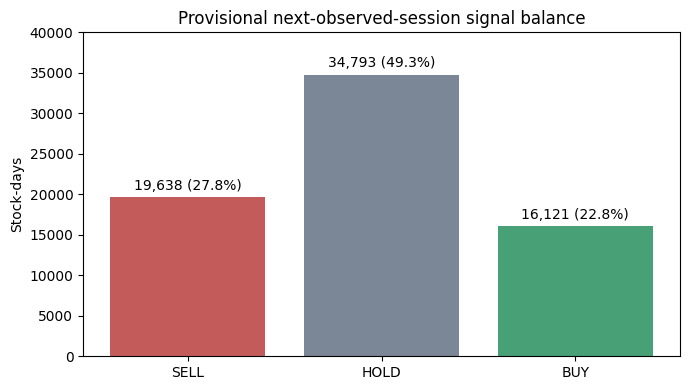

Label counts: {'SELL': 19638, 'HOLD': 34793, 'BUY': 16121}
Unlabeled final stock-days: 454


In [ ]:
trades = pl.scan_csv(
    'data/stockpati_floorsheet_full.csv',
    try_parse_dates=True,
    schema_overrides={'contract_no': pl.Int64},
)
daily_close = (trades.group_by(['symbol','date']).agg(
    pl.col('rate').sort_by('contract_no').last().alias('last_trade_close')
).collect().sort(['symbol','date']))
labelled_daily = (daily_close
    .with_columns(
        pl.col('last_trade_close').shift(-1).over('symbol').alias('next_last_trade_close'),
        pl.col('date').shift(-1).over('symbol').alias('next_trade_date'),
    )
    .with_columns((pl.col('next_last_trade_close')/pl.col('last_trade_close')-1).alias('next_return'))
    .with_columns(pl.when(pl.col('next_return').is_null()).then(None)
       .when(pl.col('next_return') > .01).then(pl.lit('BUY'))
       .when(pl.col('next_return') < -.01).then(pl.lit('SELL'))
       .otherwise(pl.lit('HOLD')).alias('signal')))
counts = labelled_daily.group_by('signal').len()
balance = {row['signal']: row['len'] for row in counts.to_dicts()}
order = ['SELL','HOLD','BUY']
values = [balance.get(k,0) for k in order]
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(order, values, color=['#c45b5b','#7b8796','#48a176'])
ax.bar_label(bars, labels=[f'{v:,} ({v/sum(values):.1%})' for v in values], padding=3)
ax.set(ylabel='Stock-days', title='Provisional next-observed-session signal balance',
       ylim=(0,max(values)*1.15))
fig.tight_layout()
plt.show()
print('Label counts:', dict(zip(order, values)))
print('Unlabeled final stock-days:', balance.get(None, 0))

HOLD is the largest class: **34,793 (49.3%)**, compared with **19,638 SELL (27.8%)** and **16,121 BUY (22.8%)**. An LSTM optimized only for accuracy could overpredict HOLD and miss BUY/SELL moves. I will derive any class weights from training dates only and assess macro F1, balanced accuracy, and per-class precision/recall against an always-HOLD baseline. These provisional labels depend on transaction-derived last prices, not authenticated published closes.

## 5. Train / validation / test split plan

I will use a **global time split**, not a random or stratified row split: earliest 70% of trading dates for training, next 15% for validation, final 15% for test. All stocks on a date stay together because they share market conditions. Each LSTM input sequence stays within one stock and uses only information known by its prediction date. I exclude an earlier-partition row if its label depends on a price in the next partition. I fit scaling and class weights on training data only, choose hyperparameters on validation, and reserve test for one final assessment. A stock-held-out split would instead test generalization to entirely unseen symbols.

In [5]:
dates = daily_close['date'].unique().sort().to_list()
train_cut = dates[int(len(dates) * .70)]
test_cut = dates[int(len(dates) * .85)]
train_rows = labelled_daily.filter(
    (pl.col('date') < train_cut) & (pl.col('next_trade_date') < train_cut)
    & pl.col('signal').is_not_null())
validation_rows = labelled_daily.filter(
    (pl.col('date') >= train_cut) & (pl.col('date') < test_cut)
    & (pl.col('next_trade_date') < test_cut) & pl.col('signal').is_not_null())
test_rows = labelled_daily.filter(
    (pl.col('date') >= test_cut) & pl.col('signal').is_not_null())
print('Train: before', train_cut, '| validation:', train_cut,
      'to before', test_cut, '| test: from', test_cut)
print('Labeled stock-days after boundary purge:',
      {'train':train_rows.height,'validation':validation_rows.height,'test':test_rows.height})

Train: before 2026-04-01 | validation: 2026-04-01 to before 2026-05-27 | test: from 2026-05-27
Labeled stock-days after boundary purge: {'train': 48089, 'validation': 10470, 'test': 11182}


## 6. Three findings that change my LSTM design

1. **Thin stock-days:** 15,065 of 71,006 stock-days (21.2%) have fewer than 20 trades, and 2,917 have only one. I will flag low-support days and evaluate performance separately there because intraday summaries from one trade are unstable.
2. **Uneven stock participation:** the ten busiest symbols contribute 16.6% of transactions. I will build one daily sequence per stock rather than one sequence per trade, so highly traded stocks do not dominate only through row count.
3. **Changing market activity:** daily trades range from 4,051 to 205,611, and reported circuit days are among the quietest. I will use robust, relative features and a forward-time test to check whether the LSTM survives different market regimes instead of learning the level of market activity alone.

## 7. Aggregate transactions to daily OHLCV per stock

I aggregate each `(symbol, date)` to a daily row. I order trades by `contract_no` for the first and final transaction rates, take the highest and lowest rates, sum share quantity for volume, and count trades. I call the final rate **last-trade close** because the published NEPSE close can use a different calculation. The contract number supplies ordering, not an intraday clock time. I keep turnover and VWAP as checks. These are unadjusted transaction prices; corporate actions require separate adjustment data.

In [ ]:
daily_ohlcv = (trades.group_by(['symbol', 'date']).agg(
    pl.col('rate').sort_by('contract_no').first().alias('open'),
    pl.col('rate').max().alias('high'),
    pl.col('rate').min().alias('low'),
    pl.col('rate').sort_by('contract_no').last().alias('last_trade_close'),
    pl.col('quantity').sum().alias('volume'),
    pl.col('amount').sum().alias('turnover'),
    pl.len().alias('trade_count'),
).with_columns((pl.col('turnover') / pl.col('volume')).alias('vwap'))
 .collect().sort(['symbol', 'date']))
print('Daily stock rows:', daily_ohlcv.height)
print('Range:', daily_ohlcv['date'].min(), 'to', daily_ohlcv['date'].max())
print(daily_ohlcv.filter(
    (pl.col('date') == pl.date(2025, 7, 17))
    & pl.col('symbol').is_in(['BBC', 'HBL', 'SHIVM'])
).select(['symbol','open','high','low','last_trade_close','volume','trade_count']).to_dicts())

Daily stock rows: 71006
Range: 2025-07-17 to 2026-07-22
[{'symbol': 'BBC', 'open': 5410.0, 'high': 5480.0, 'low': 5400.1, 'last_trade_close': 5480.0, 'volume': 819, 'trade_count': 51}, {'symbol': 'HBL', 'open': 241.0, 'high': 261.0, 'low': 236.0, 'last_trade_close': 249.0, 'volume': 407528, 'trade_count': 1088}, {'symbol': 'SHIVM', 'open': 542.0, 'high': 570.0, 'low': 542.0, 'last_trade_close': 568.9, 'volume': 568742, 'trade_count': 2447}]


### Published-price spot check

I compared three stocks on **2025-07-17** with the [published unadjusted NEPSE daily-price CSV](https://github.com/socrateai-official/nepse-open-data/blob/main/ohlc_unadjusted_stock/unadj_2025-07-17.csv). This is an independently published NEPSE dataset, not an authenticated exchange export. Its repository describes the [unadjusted OHLC files](https://github.com/socrateai-official/nepse-open-data). I record the reference values below so this notebook remains runnable without a network request. The comparison verifies some fields and surfaces discrepancies; I do not silently replace floorsheet values.

In [7]:
published_sample = pl.DataFrame({
    'symbol': ['BBC', 'HBL', 'SHIVM'],
    'published_open': [5410.0, 241.0, 542.0],
    'published_high': [5480.0, 261.0, 570.0],
    'published_low': [5400.1, 236.0, 542.0],
    'published_close': [5471.17, 248.56, 567.29],
    'published_volume': [819, 407510, 568683],
})
spot = (daily_ohlcv.filter(pl.col('date') == pl.date(2025, 7, 17))
        .join(published_sample, on='symbol', how='inner')
        .select('symbol','open','published_open','high','published_high',
                'low','published_low','last_trade_close','published_close',
                'volume','published_volume')
        .sort('symbol'))
print(spot.to_dicts())
print('Exact open/high/low matches:',
      spot.select([(pl.col(a) == pl.col('published_'+a)).sum().alias(a)
                   for a in ['open','high','low']]).to_dicts())
print('Volume differences:', spot.select(
    'symbol', (pl.col('volume')-pl.col('published_volume')).alias('shares')
).to_dicts())

[{'symbol': 'BBC', 'open': 5410.0, 'published_open': 5410.0, 'high': 5480.0, 'published_high': 5480.0, 'low': 5400.1, 'published_low': 5400.1, 'last_trade_close': 5480.0, 'published_close': 5471.17, 'volume': 819, 'published_volume': 819}, {'symbol': 'HBL', 'open': 241.0, 'published_open': 241.0, 'high': 261.0, 'published_high': 261.0, 'low': 236.0, 'published_low': 236.0, 'last_trade_close': 249.0, 'published_close': 248.56, 'volume': 407528, 'published_volume': 407510}, {'symbol': 'SHIVM', 'open': 542.0, 'published_open': 542.0, 'high': 570.0, 'published_high': 570.0, 'low': 542.0, 'published_low': 542.0, 'last_trade_close': 568.9, 'published_close': 567.29, 'volume': 568742, 'published_volume': 568683}]
Exact open/high/low matches: [{'open': 3, 'high': 3, 'low': 3}]
Volume differences: [{'symbol': 'BBC', 'shares': 0}, {'symbol': 'HBL', 'shares': 18}, {'symbol': 'SHIVM', 'shares': 59}]


I found exact open, high, and low matches for all three examples. The floorsheet final-trade rates differ from all three published closes; BBC volume matches, while HBL and SHIVM differ by 18 and 59 shares. I will use the floorsheet-derived series only as a **proxy** for close and will not claim it reproduces official close/volume exactly. Before a production price model, I would obtain exchange-authenticated daily prices and reconcile canceled/corrected trades and the exchange close methodology.

## 8. Trades, volume, and active stocks per day; holidays and circuits

My CSV spans **2025-07-17 to 2026-07-22**, so it does **not** contain two years. I plot every calendar date in that available span; zero bars on missing dates mean no transactions in this file and do not by themselves prove a holiday. I mark the selected 2025 Dashain and Tihar public-holiday windows, which also contain no rows in the CSV, using the [Nepal public-holiday list](https://pradhanlaw.com/publications/list-of-public-holidays-2082-bs-202526-ad). I mark **2025-09-18** and **2026-03-09** as reported exchange-wide circuit-breaker days using [Kathmandu Post coverage](https://kathmandupost.com/money/2025/09/18/nepse-plunges-160-points-trading-halted) and [Kathmandu Post coverage](https://kathmandupost.com/money/2026/03/09/nepse-closes-after-three-circuit-breakers-triggered-by-6-percent-surge). These holiday marks are not a complete exchange calendar. I do not infer any other circuit days from price moves alone.

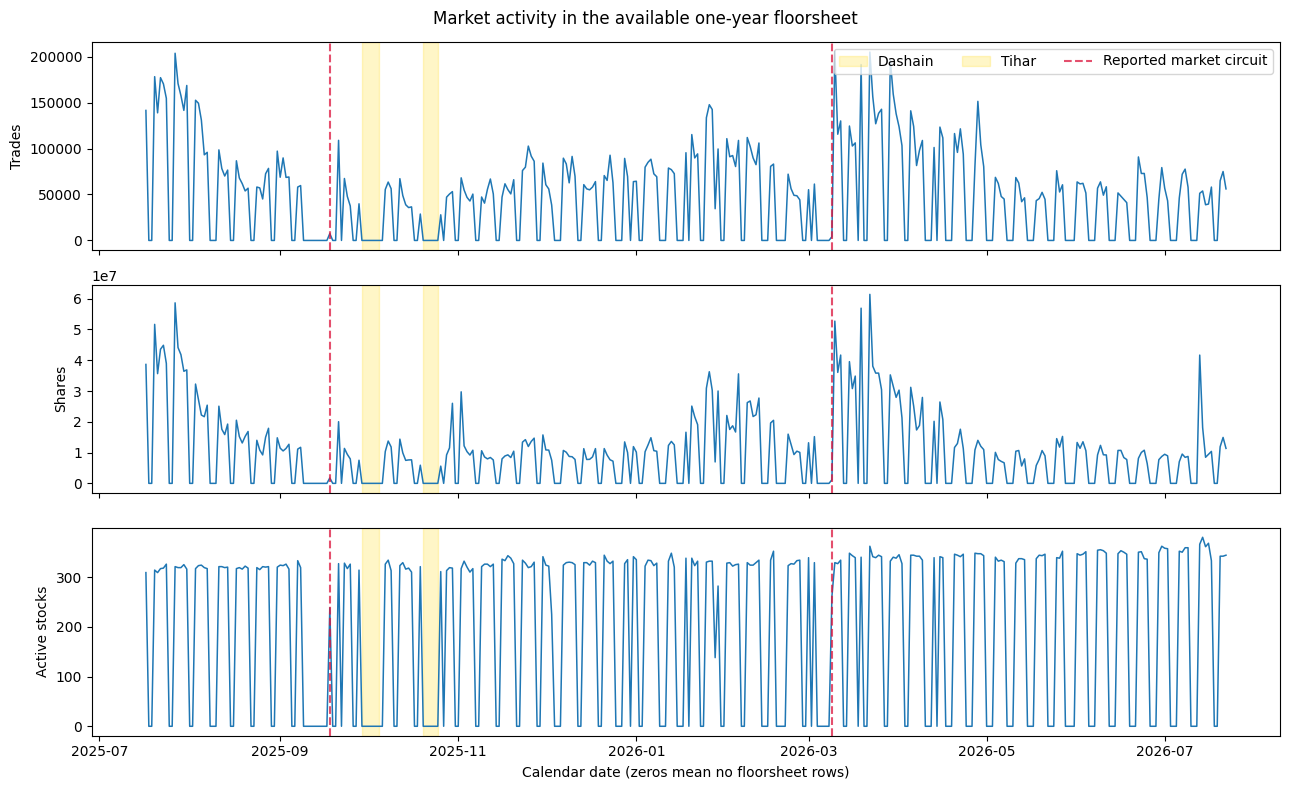

Trading dates: 215 | calendar range: 2025-07-17 to 2026-07-22
Reported circuit-day activity: {datetime.date(2025, 9, 18): {'trades': 7435, 'volume': 1752781, 'active_stocks': 238}, datetime.date(2026, 3, 9): {'trades': 4051, 'volume': 1143767, 'active_stocks': 261}}


In [ ]:
market_daily = (daily_ohlcv.group_by('date').agg(
    pl.col('trade_count').sum().alias('trades'),
    pl.col('volume').sum().alias('volume'),
    pl.len().alias('active_stocks'),
).sort('date').to_dicts())
market_daily = pd.DataFrame(market_daily).set_index('date')
calendar = pd.date_range(market_daily.index.min(), market_daily.index.max(), freq='D')
market_calendar = market_daily.reindex(calendar, fill_value=0)
holidays = [
    (pd.Timestamp('2025-09-29'), pd.Timestamp('2025-10-04'), 'Dashain'),
    (pd.Timestamp('2025-10-20'), pd.Timestamp('2025-10-24'), 'Tihar'),
]
circuits = [pd.Timestamp('2025-09-18'), pd.Timestamp('2026-03-09')]
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, col, ylabel in zip(axes, ['trades','volume','active_stocks'],
                            ['Trades', 'Shares', 'Active stocks']):
    ax.plot(market_calendar.index, market_calendar[col], lw=1.1)
    ax.set_ylabel(ylabel)
    for start, end, name in holidays:
        ax.axvspan(start, end + pd.Timedelta(days=1), color='gold', alpha=.22,
                   label=name if ax is axes[0] else None)
    for date in circuits:
        ax.axvline(date, color='crimson', linestyle='--', alpha=.75,
                   label='Reported market circuit' if ax is axes[0] and date == circuits[0] else None)
axes[0].legend(loc='upper right', ncol=3)
axes[-1].set_xlabel('Calendar date (zeros mean no floorsheet rows)')
fig.suptitle('Market activity in the available one-year floorsheet')
fig.tight_layout()
plt.show()
print('Trading dates:', len(market_daily),
      '| calendar range:', calendar.min().date(), 'to', calendar.max().date())
print('Reported circuit-day activity:', market_daily.loc[circuits].to_dict('index'))

## 9. Intraday trade count and volume by time of day

I cannot calculate trade count or volume by hour from this file: its columns contain a **date** and a **contract number**, but no trade timestamp or time-of-day field. A contract number gives sequence, not clock time. I therefore leave the requested intraday distribution unavailable until timestamped trades are supplied. I will not derive fake times from contract numbers.

In [9]:
print('Columns:', df.columns.to_list())
print('Timestamp/time-of-day columns:',
      [c for c in df.columns if any(k in c.lower() for k in
       ('timestamp', 'trade_time', 'execution_time', 'time_of_day'))])

Columns: ['date', 'symbol', 'company_name', 'contract_no', 'buyer_broker_code', 'buyer_broker_name', 'seller_broker_code', 'seller_broker_name', 'quantity', 'rate', 'amount']
Timestamp/time-of-day columns: []


## 10. Broker activity and concentration

I count shares on the buyer and seller side separately; every trade contributes its quantity to one buyer and one seller. For each stock, I measure the largest buyer-broker share of its total bought volume and the buyer-side Herfindahl index (sum of squared broker shares). These are descriptive concentration measures, not proof of manipulation. I examine low-volume symbols separately because one or two trades can mechanically produce 100% concentration.

In [10]:
buyer_volume = (trades.group_by(['buyer_broker_code','buyer_broker_name'])
                .agg(pl.col('quantity').sum().alias('bought_shares'))
                .sort('bought_shares', descending=True).collect())
seller_volume = (trades.group_by(['seller_broker_code','seller_broker_name'])
                 .agg(pl.col('quantity').sum().alias('sold_shares'))
                 .sort('sold_shares', descending=True).collect())
print('Top buyer brokers:', buyer_volume.head(5).to_dicts())
print('Top seller brokers:', seller_volume.head(5).to_dicts())

stock_buyer = (trades.group_by(['symbol','buyer_broker_code'])
               .agg(pl.col('quantity').sum().alias('broker_shares')).collect())
stock_concentration = (stock_buyer.group_by('symbol').agg(
    pl.col('broker_shares').sum().alias('stock_volume'),
    (pl.col('broker_shares').max()/pl.col('broker_shares').sum()).alias('top_buyer_share'),
    ((pl.col('broker_shares')/pl.col('broker_shares').sum())**2).sum().alias('buyer_hhi'),
    pl.len().alias('buyer_brokers'),
).sort('symbol'))
print('Median top-buyer share:', round(stock_concentration['top_buyer_share'].median(), 3))
print('Most concentrated stocks with >=100,000 bought shares:',
      stock_concentration.filter(pl.col('stock_volume') >= 100_000)
      .sort('top_buyer_share', descending=True).head(5).to_dicts())

Top buyer brokers: [{'buyer_broker_code': 58, 'buyer_broker_name': 'Naasa Securities Co. Ltd.', 'bought_shares': 232051156}, {'buyer_broker_code': 34, 'buyer_broker_name': 'Vision Securities Pvt. Ltd.', 'bought_shares': 172231068}, {'buyer_broker_code': 42, 'buyer_broker_name': 'Sani Securities Co. Ltd.', 'bought_shares': 145188859}, {'buyer_broker_code': 49, 'buyer_broker_name': 'Online Securities Pvt. Ltd.', 'bought_shares': 130794120}, {'buyer_broker_code': 44, 'buyer_broker_name': 'Dynamic Money Managers Securities Pvt. Ltd.', 'bought_shares': 116199386}]
Top seller brokers: [{'seller_broker_code': 58, 'seller_broker_name': 'Naasa Securities Co. Ltd.', 'sold_shares': 242658444}, {'seller_broker_code': 34, 'seller_broker_name': 'Vision Securities Pvt. Ltd.', 'sold_shares': 157288769}, {'seller_broker_code': 49, 'seller_broker_name': 'Online Securities Pvt. Ltd.', 'sold_shares': 130950842}, {'seller_broker_code': 48, 'seller_broker_name': 'Trishakti Securities Public Limited', 'sold_

## 11. Exact signal definition and class balance

For stock `s` on date `t`, I define the supervised target as `r(s,t) = last_trade_close(s, next observed stock session) / last_trade_close(s,t) - 1`. The label is **BUY** if `r > 0.01`, **SELL** if `r < -0.01`, and **HOLD** if `-0.01 <= r <= 0.01`. This is the stock's next **observed** trading session, not necessarily the exchange's next trading day. I leave the last observed day of each stock unlabeled. I chose the 1% threshold for this exploratory analysis; I have not optimized it. The floorsheet's final trade price differs from some published closing prices, so I will reconcile official closes and corporate actions before relying on this signal for a trading model.

The class balance is **19,638 SELL (27.8%)**, **34,793 HOLD (49.3%)**, and **16,121 BUY (22.8%)** among 70,552 labeled stock-days; **454** final stock-days have no label. HOLD is nearly half the sample and more than twice as common as BUY. If I optimize overall accuracy alone, my LSTM may favor HOLD and miss actionable moves. I will calculate class weights from training data only, compare with an always-HOLD baseline, and report macro F1, balanced accuracy, per-class precision and recall, and a confusion matrix on the chronological test set. I will never use future prices or the label as model inputs.

In [11]:
class_balance = pl.DataFrame({
    'signal': ['SELL', 'HOLD', 'BUY'],
    'stock_days': [balance['SELL'], balance['HOLD'], balance['BUY']],
}).with_columns((100 * pl.col('stock_days') / sum(values)).round(1).alias('percent'))
print(class_balance.to_dicts())

[{'signal': 'SELL', 'stock_days': 19638, 'percent': 27.8}, {'signal': 'HOLD', 'stock_days': 34793, 'percent': 49.3}, {'signal': 'BUY', 'stock_days': 16121, 'percent': 22.8}]
